In [1]:
import sys
from likelihood import MDCGaussianNoise, subtract_signal
from pycbc.conversions import mchirp_from_mass1_mass2, mass1_from_mchirp_q, mass2_from_mchirp_q
from pycbc.types import FrequencySeries
from plot_results import convert_signal, comparison_signals, comparison_freq, qtrans_plot, gwpy_to_pycbc, pycbc_to_gwpy
sys.path.append('/home/victor-glorieux/Internship_Victor_CBC_ET')
from fonctions import instruments_PSD, antenna_factors, comparison_signals_params
from generation_signal import generation_signal_GW
from generate_data import generate_frequency_domain_signal
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

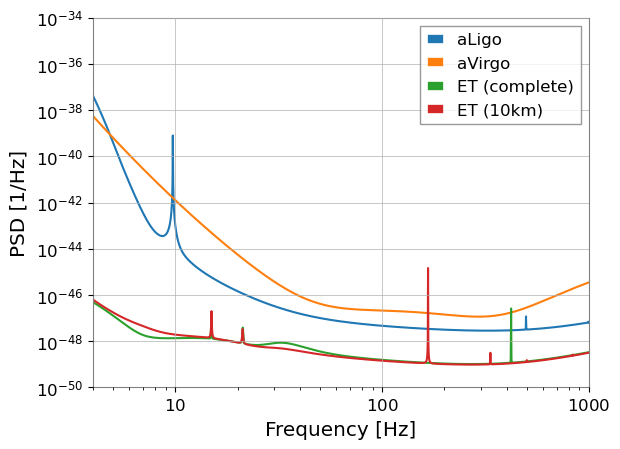

In [2]:
dict = {'aLigo' : 'aLIGOAPlusDesignSensitivityT1800042',
        'aVirgo' : 'AdvVirgo',
        'ET (complete)' : 'EinsteinTelescopeP1600143'}

instruments_PSD(dict,ET_MDC = True)

Waveform approximate duration: 2193.3s
Segment duration: 4096.0s
{'E1': <pycbc.types.frequencyseries.FrequencySeries object at 0x7f38b5854220>, 'E2': <pycbc.types.frequencyseries.FrequencySeries object at 0x7f3877ca6c70>, 'E3': <pycbc.types.frequencyseries.FrequencySeries object at 0x7f3877ca6fd0>}


Waveform approximate duration: 2193.3s
Segment duration: 4096.0s


/home/victor-glorieux/.conda/envs/cop_adrian/lib/python3.9/site-packages/gwpy/types/series.py:131: UserWarning: xindex was given to TimeSeries(), x0 will be ignored
  warn("xindex was given to %s(), x0 will be ignored"


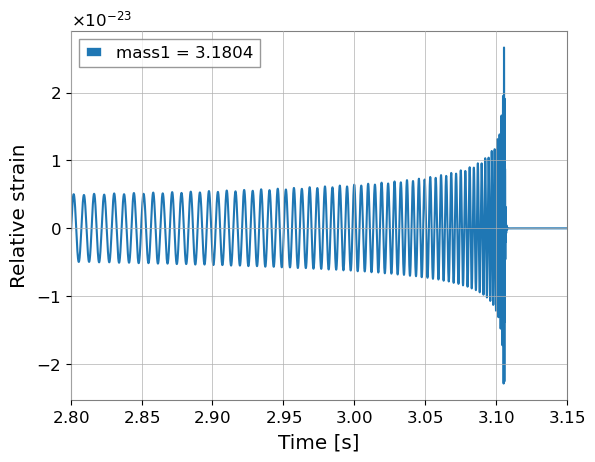

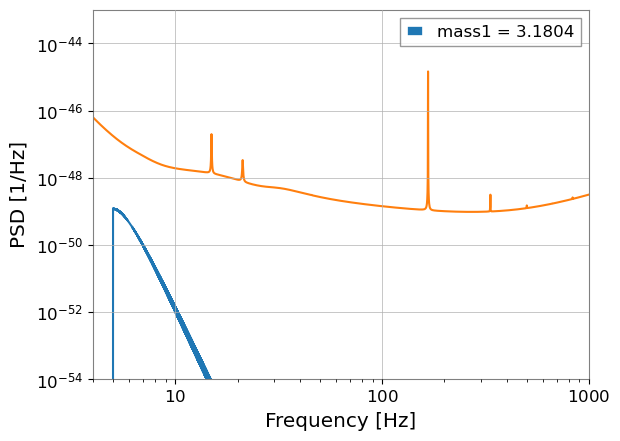

In [2]:
# cbc_params = {
#               'mass1': 38.6,
#               'mass2': 29.3,
#               'spin1x': 0., 'spin2x': 0.,  'spin1y': 0., 'spin2y': 0.,  'spin1z': 0, 'spin2z': 0, 
#               'eccentricity': 0,
#               'ra': 1.37, 'dec': -1.26, 'distance': 500, 
#               'polarization': 2.76, 'inclination': 0,
#               'tc': 3.1 , 'coa_phase': 0.3,
#               'approximant': 'IMRPhenomXPHM',
#               'f_lower': 5
#                 }


cbc_params = {
              'mass1': 3.180400e+00,
              'mass2': 2.227131e+00,
              'spin1x': 0., 'spin2x': 0.,  'spin1y': 0., 'spin2y': 0.,  'spin1z': 0, 'spin2z': 0, 
              'eccentricity': 0,
              'ra': -3.065290e-01, 'dec': 2.901400e-01, 'distance': 9.536026e+02, 
              'polarization': 2.283565e+00, 'inclination': 2.586509e+00,
              'tc': 3.1 , 'coa_phase': 5.331577e+00,
              'approximant': 'IMRPhenomXPHM',
              'f_lower': 5, 'z' : 1.895000e-01
                }

ifos=['E1', 'E2', 'E3']
signal = generate_frequency_domain_signal(cbc_params, ifos=ifos)
print(signal)
ts_signal = {}
psds = {}
psd_file = '../input/ET10km_columns.txt'
psd = np.loadtxt(psd_file, usecols=(0,3))
psd_of_f = interp1d(psd[:,0], psd[:,1], bounds_error=False, fill_value=(psd[0,1], psd[-1,1]))

for ifo in ifos :
    ts_signal[ifo] = signal[ifo].to_timeseries()

    freq_array = signal[ifo].get_sample_frequencies()
    delta_f = signal[ifo].get_delta_f()
    psd_pycbc = psd_of_f(freq_array)
    psd_pycbc = FrequencySeries(psd_pycbc, delta_f=delta_f)
    psds[ifo] = psd_pycbc


model = MDCGaussianNoise(signal, psds)



mass1 = {'param' : 'mass1', 'A' : 3.180400e+00}
spins = {'param' : 'spin1z', 'A' : 1, 'B' : 0, 'C' : -1}
# mchirp = {'A' : round(mchirp_from_mass1_mass2(mass1['A'],mass2),1),'B' : round(mchirp_from_mass1_mass2(mass1['B'],mass2),1),
#           'C' : round(mchirp_from_mass1_mass2(mass1['C'],mass2),2)}

comparison_signals_params(model,mass1,cbc_params)
